# 02 - Baseline: Ingestão de `.jpg` soltos (Pipeline A)

**Hipótese:** num pipeline de inferência com a GPU otimizada (MobileNetV2 *forward-only* + mixed
precision FP16 + batch grande), a GPU consome imagens **mais rápido do que a CPU consegue
decodificar os `.jpg`**. Ler milhares de arquivos soltos e decodificá-los na CPU vira o gargalo,
**deixando a GPU ociosa (GPU Starvation)** e derrubando o **Throughput** (imagens/segundo).

**O que este notebook faz:**
1. Monta um pipeline `tf.data` otimizado (paralelismo + prefetch) lendo `/tf/data/raw_jpg/*.jpg`.
2. Usa uma `MobileNetV2` (pesos ImageNet) em **inferência** (forward-only) + **FP16** como consumidor
   rápido de GPU.
3. Roda **N_ROUNDS** rodadas medindo, via thread paralela (`psutil` + `nvidia-ml-py`), CPU%,
   RAM do contêiner (via cgroup) e GPU% a cada ~1s.
4. Calcula **Média ± Desvio Padrão** do Throughput, plota os gráficos e exporta `.csv`.

Este é o **Pipeline A** (ingênuo: `.jpg` soltos). Será comparado com o **Pipeline B**
(`.parquet` pré-decodificado via Spark) nos notebooks 03/04.

> Roda dentro do contêiner (4GB RAM / 2 vCPUs). Os caminhos usam `/tf/data`.

In [1]:
#importanto as bibliotecas
import os
import time
import threading
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import pynvml
import tensorflow as tf

# Mixed precision (FP16): corta pela metade a VRAM de ativacao (cabe batch maior) e usa os
# tensor cores (mais rapido). DEVE ser configurado ANTES de construir o modelo.
tf.keras.mixed_precision.set_global_policy("mixed_float16")

# Configs iniciais do experimento
DATA_GLOB    = "/tf/data/raw_jpg/*.jpg"   # Path das imagens soltas
RESULTS_DIR  = Path("/tf/data/results")   # Saida dos CSVs do experimento
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE     = (224, 224)   # Tamanho de entrada da MobileNetV2
BATCH_SIZE   = 256          # Batch grande: forward usa pouca VRAM e amortiza o overhead por passo
N_IMAGES     = None         # None = TODAS as imagens do dataset; um inteiro = subset (teste rapido)
N_PASSES     = 1            # Passadas por rodada. 1 basta com o dataset inteiro; suba se usar subset
N_ROUNDS     = 3            # Rodadas (para media e desvio padrao)
SAMPLE_EVERY = 1.0          # Intervalo de amostragem do monitor em s

# Evita que o TF reserve 100% da VRAM de uma vez - aloca conforme necessario (ajuda o pynvml medir)
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("memory_growth:", e)

print("TensorFlow:", tf.__version__)
print("Policy    :", tf.keras.mixed_precision.global_policy().name)
print("GPUs visiveis:", tf.config.list_physical_devices("GPU"))
print("Resultados em:", RESULTS_DIR)

2026-07-01 01:49:01.587149: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-01 01:49:01.593870: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-01 01:49:01.601530: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-01 01:49:01.603888: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-01 01:49:01.610209: I tensorflow/core/platform/cpu_feature_guar

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 5060, compute capability 12.0
TensorFlow: 2.17.0
Policy    : mixed_float16
GPUs visiveis: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Resultados em: /tf/data/results


I0000 00:00:1782870542.665497   18792 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782870542.694481   18792 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782870542.697861   18792 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782870542.699903   18792 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [2]:
# Inicializa o nvidia-ml-py(pynvml) pra pegar os dados de GPU, se n tiver GPU ou se o pynvml n estiver instalado, ignora e continua
try:
    pynvml.nvmlInit()
    GPU_HANDLE = pynvml.nvmlDeviceGetHandleByIndex(0)
    gpu_name = pynvml.nvmlDeviceGetName(GPU_HANDLE)
    if isinstance(gpu_name, bytes): # Pega o handle da GPU e o nome, se o nome for bytes, decodifica pra string
        gpu_name = gpu_name.decode()
    print(f"GPU detectada: {gpu_name}")
except Exception as e:
    GPU_HANDLE = None
    print("pynvml indisponível ou n foi possível achar a GPU, GPU não será monitorada:", e)

GPU detectada: NVIDIA GeForce RTX 5060


In [3]:
# file_path e o caminho do arquivo, ex: /tf/data/raw_jpg/cat.1.jpg
def get_label(file_path):
    # Usa TF strings, pq dentro do tf.data o processamento roda em modo grafo
    fname = tf.strings.split(file_path, os.sep)[-1]
    is_cat = tf.strings.regex_full_match(tf.strings.lower(fname), "cat.*")
    return tf.cast(tf.where(is_cat, 0, 1), tf.float32)   # 0.0 gato, 1.0 cachorro


def process_path(file_path):
    label = get_label(file_path)
    img = tf.io.read_file(file_path)                             # le os bytes do disco
    img = tf.io.decode_jpeg(img, channels=3)                     # DECODE na CPU -> o gargalo mora aqui
    img = tf.image.resize(img, IMG_SIZE)                         # resize na CPU
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)  # normaliza p/ MobileNetV2 ([-1, 1])
    return img, label


def build_dataset(batch_size):
    # from_tensor_slices sobre ALL_FILES; shuffle espalha a leitura pelo disco
    ds = tf.data.Dataset.from_tensor_slices(ALL_FILES)
    ds = ds.shuffle(len(ALL_FILES), reshuffle_each_iteration=True)
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)                          # sobrepoe decode (CPU) e inferencia (GPU)
    return ds


# N_IMAGES=None -> usa TODAS as imagens do dataset; senao um subset (teste rapido). O tamanho nao
# afeta as TAXAS medidas (gargalo e o decode por imagem), so a duracao/estabilidade das rodadas.
ALL_FILES = tf.io.gfile.glob(DATA_GLOB)
if N_IMAGES is not None:
    ALL_FILES = ALL_FILES[:N_IMAGES]
if len(ALL_FILES) == 0:
    raise FileNotFoundError(f"Nenhum .jpg em {DATA_GLOB}. Rode o 01_download.ipynb antes.")
print(f"Imagens no dataset: {len(ALL_FILES):,}  (N_IMAGES={N_IMAGES})")

Imagens no dataset: 70,433  (N_IMAGES=None)


In [4]:
# Consumidor de GPU: MobileNetV2 (ImageNet) em INFERENCIA (forward-only) + FP16.
# Modelo leve: consome imagens MUITO mais rapido que a CPU decodifica -> o gargalo cai
# na ingestao (.jpg) e a GPU aparece faminta (starvation bem mais acentuado que a ResNet50).
def build_model():
    base = tf.keras.applications.MobileNetV2(
        weights="imagenet", include_top=False,
        input_shape=(*IMG_SIZE, 3), pooling="avg",
    )
    # dtype="float32" na saida: boa pratica de mixed precision (estabilidade numerica)
    out = tf.keras.layers.Dense(1, activation="sigmoid", dtype="float32")(base.output)
    return tf.keras.Model(base.input, out)


model = build_model()


@tf.function
def infer(x):
    return model(x, training=False)      # forward-only, compilado em grafo (caminho rapido)


print("Modelo pronto (MobileNetV2, inferencia + FP16). Parametros:", f"{model.count_params():,}")

I0000 00:00:1782870542.864744   18792 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782870542.868368   18792 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782870542.869550   18792 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782870542.944679   18792 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

9406464/9406464 [==============================] - 0s 0us/step
Modelo pronto (MobileNetV2, inferencia + FP16). Parametros: 2,259,265


In [5]:
# ---------------------------------------------------------------------------
# Thread de monitoramento: amostra CPU%, RAM e GPU% a cada SAMPLE_EVERY s.
# ---------------------------------------------------------------------------
# Dentro do Docker, o psutil le /proc do HOST -> nao respeita os limites do cgroup.
# Corrigimos DUAS metricas lendo o cgroup direto:
#   - CPU: normalizada pelos vCPUs do conteiner (senao 2 vCPUs a 100% viram ~17%).
#   - RAM: memory.current do conteiner (senao psutil reporta a RAM do HOST inteiro,
#          ex.: 7.8 GB num conteiner limitado a 4 GB).

import os


def detect_container_cpu_quota():
    """Numero de vCPUs disponiveis ao conteiner (float)."""
    # cgroup v2
    try:
        with open("/sys/fs/cgroup/cpu.max") as f:
            quota_str, period_str = f.read().strip().split()
        if quota_str != "max":
            return float(quota_str) / float(period_str)
    except (FileNotFoundError, OSError, ValueError):
        pass
    # cgroup v1
    try:
        with open("/sys/fs/cgroup/cpu/cpu.cfs_quota_us") as f:
            quota = int(f.read().strip())
        with open("/sys/fs/cgroup/cpu/cpu.cfs_period_us") as f:
            period = int(f.read().strip())
        if quota > 0:
            return quota / period
    except (FileNotFoundError, OSError, ValueError):
        pass
    # Fallback: CPUs visiveis ao processo (cpuset) ou logicos
    try:
        return float(len(os.sched_getaffinity(0)))
    except (AttributeError, OSError):
        return float(os.cpu_count() or 1)


def read_container_mem():
    """(usado_gb, limite_gb) da memoria do CONTEINER via cgroup (inclui page cache)."""
    # cgroup v2
    try:
        with open("/sys/fs/cgroup/memory.current") as f:
            used = int(f.read().strip())
        with open("/sys/fs/cgroup/memory.max") as f:
            lim = f.read().strip()
        limit = None if lim == "max" else int(lim)
        return used / 1024 ** 3, (limit / 1024 ** 3 if limit else float("nan"))
    except (FileNotFoundError, OSError, ValueError):
        pass
    # cgroup v1
    try:
        with open("/sys/fs/cgroup/memory/memory.usage_in_bytes") as f:
            used = int(f.read().strip())
        with open("/sys/fs/cgroup/memory/memory.limit_in_bytes") as f:
            limit = int(f.read().strip())
        limit = limit if limit < (1 << 62) else None
        return used / 1024 ** 3, (limit / 1024 ** 3 if limit else float("nan"))
    except (FileNotFoundError, OSError, ValueError):
        return float("nan"), float("nan")


N_HOST_CPUS      = psutil.cpu_count(logical=True)
N_CONTAINER_CPUS = detect_container_cpu_quota()
_, CONTAINER_MEM_LIMIT_GB = read_container_mem()
print(f"vCPUs do conteiner (cgroup): {N_CONTAINER_CPUS}")
print(f"Limite de RAM (cgroup)     : {CONTAINER_MEM_LIMIT_GB:.1f} GB")
print("=> `cpu_pct` = % dos vCPUs do conteiner; `cont_mem_used_gb` = RAM do conteiner.")


class ResourceMonitor(threading.Thread):
    """
    Captura a cada `interval` s:

      cpu_pct           % dos vCPUs do CONTEINER (0-100). METRICA PRINCIPAL de CPU: saturada
                        (~100%) durante o pipeline = decode dos .jpg e o gargalo.
      cpu_pct_host      % medio do HOST (12 threads). So referencia/debug.
      proc_cpu_raw      % do processo sobre 1 vCPU (pode > 100).
      cont_mem_used_gb  RAM do CONTEINER via cgroup (METRICA PRINCIPAL de RAM; inclui page cache).
      proc_rss_gb       RSS do processo Python (working set).
      ram_used_host_gb  RAM usada no HOST inteiro. So referencia; NAO usar como prova.
      gpu_util_pct      Utilizacao da GPU (pynvml). BAIXA durante o pipeline = GPU faminta.
      gpu_mem_gb        VRAM ocupada.
    """

    def __init__(self, gpu_handle, interval=1.0,
                 n_container_cpus=N_CONTAINER_CPUS):
        super().__init__(daemon=True)
        self.handle = gpu_handle
        self.interval = interval
        self.n_container_cpus = max(float(n_container_cpus), 1e-6)  # evita divisao por zero
        self._stop_event = threading.Event()
        self.samples = []
        self.proc = psutil.Process()

    def run(self):
        psutil.cpu_percent(None)        # prime: 1a leitura e descartavel
        self.proc.cpu_percent(None)
        t_start = time.time()
        while not self._stop_event.is_set():
            cpu_host     = psutil.cpu_percent(None)
            proc_cpu_raw = self.proc.cpu_percent(None)
            cpu_container = min(proc_cpu_raw / self.n_container_cpus, 100.0)

            cont_used_gb, _  = read_container_mem()
            proc_rss_gb      = self.proc.memory_info().rss / (1024 ** 3)
            ram_used_host_gb = psutil.virtual_memory().used / (1024 ** 3)

            gpu_util, gpu_mem_gb = np.nan, np.nan
            if self.handle is not None:
                try:
                    gpu_util   = float(pynvml.nvmlDeviceGetUtilizationRates(self.handle).gpu)
                    gpu_mem_gb = pynvml.nvmlDeviceGetMemoryInfo(self.handle).used / (1024 ** 3)
                except Exception:
                    pass

            self.samples.append({
                "t_rel":            time.time() - t_start,
                "cpu_pct":          cpu_container,    # PRINCIPAL (escala do conteiner)
                "cpu_pct_host":     cpu_host,         # referencia (escala do host)
                "proc_cpu_raw":     proc_cpu_raw,     # bruto do processo (pode > 100)
                "cont_mem_used_gb": cont_used_gb,     # PRINCIPAL (RAM do conteiner via cgroup)
                "proc_rss_gb":      proc_rss_gb,      # working set do processo
                "ram_used_host_gb": ram_used_host_gb, # referencia (RAM do host inteiro)
                "gpu_util_pct":     gpu_util,
                "gpu_mem_gb":       gpu_mem_gb,
            })
            self._stop_event.wait(self.interval)

    def stop(self):
        self._stop_event.set()
        self.join()
        return pd.DataFrame(self.samples)

vCPUs do conteiner (cgroup): 2.0
Limite de RAM (cgroup)     : 4.0 GB
=> `cpu_pct` = % dos vCPUs do conteiner; `cont_mem_used_gb` = RAM do conteiner.


In [ ]:
round_summaries = []   # 1 linha por rodada (metricas agregadas)
raw_samples = []       # serie temporal de todas as amostras (p/ graficos)

# Warmup (FORA do cronometro): traca o @tf.function + esquenta o pipeline/disco, pra a
# rodada 1 nao carregar o custo do 1o tracado + leitura fria e inflar o desvio padrao.
_ds_warm = build_dataset(BATCH_SIZE)
for x, _ in _ds_warm.take(5):
    infer(x)

for r in range(1, N_ROUNDS + 1):
    print(f"\n===== Rodada {r}/{N_ROUNDS} =====")
    ds = build_dataset(BATCH_SIZE)     # dataset (N_IMAGES), shuffle -> decode a cada passada

    monitor = ResourceMonitor(GPU_HANDLE, interval=SAMPLE_EVERY)
    monitor.start()

    n_images = 0
    t0 = time.time()
    for _ in range(N_PASSES):          # varias passadas -> rodada longa o bastante p/ estatistica
        for x, y in ds:                # y (label) nao e usado na inferencia
            infer(x)                   # forward-only na GPU (consumidor rapido)
            n_images += int(x.shape[0])
    elapsed = time.time() - t0

    df_s = monitor.stop()
    df_s["round"] = r
    raw_samples.append(df_s)

    throughput = n_images / elapsed
    summary = {
        "round": r,
        "n_images": n_images,
        "round_time_s": elapsed,
        "throughput_img_s": throughput,
        "cpu_mean_pct": df_s["cpu_pct"].mean(),
        "cpu_max_pct": df_s["cpu_pct"].max(),
        "cont_mem_peak_gb": df_s["cont_mem_used_gb"].max(),
        "proc_rss_peak_gb": df_s["proc_rss_gb"].max(),
        "ram_host_peak_gb": df_s["ram_used_host_gb"].max(),
        "gpu_util_mean_pct": df_s["gpu_util_pct"].mean(),
        "gpu_util_max_pct": df_s["gpu_util_pct"].max(),
        "gpu_mem_peak_gb": df_s["gpu_mem_gb"].max(),
    }
    round_summaries.append(summary)
    print(f"  imagens={n_images:,} | tempo={elapsed:.1f}s | "
          f"throughput={throughput:.1f} img/s | "
          f"CPU medio={summary['cpu_mean_pct']:.0f}% | "
          f"GPU media={summary['gpu_util_mean_pct']:.0f}%")

summary_df = pd.DataFrame(round_summaries)
raw_df = pd.concat(raw_samples, ignore_index=True)
summary_df

In [7]:
# ---------------------------------------------------------------------------
# TETOS ISOLADOS (img/s): quanto a CPU (decode) e a GPU (forward) aguentam sozinhas.
# ---------------------------------------------------------------------------
# Quantifica o starvation: o pipeline .jpg fica preso perto do teto da CPU (produtor),
# bem abaixo do teto da GPU (consumidor). A diferenca = capacidade de GPU desperdicada.
# N_ROUNDS repeticoes de cada -> media +/- desvio, igual ao pipeline.

# Batch fixo (ja decodificado) p/ o teto da GPU: forward puro, sem I/O/decode/cache.
x_fixed, _ = next(iter(build_dataset(BATCH_SIZE)))
infer(x_fixed)                                   # warmup: traca o grafo (fora do cronometro)
N_STEPS = max(30, 15000 // BATCH_SIZE)           # ~15k imgs por rodada no teste da GPU

cpu_ceils, gpu_ceils = [], []
for r in range(1, N_ROUNDS + 1):
    # (a) TETO DA CPU: decode puro, sem GPU (produtor)
    ds_cpu = build_dataset(BATCH_SIZE)
    n, t0 = 0, time.time()
    for _ in range(N_PASSES):
        for x, y in ds_cpu:
            n += int(x.shape[0])
    cpu_ceils.append(n / (time.time() - t0))

    # (b) TETO DA GPU: forward sobre 1 batch fixo (consumidor), sem I/O
    n, t0 = 0, time.time()
    for _ in range(N_STEPS):
        infer(x_fixed)
        n += int(x_fixed.shape[0])
    gpu_ceils.append(n / (time.time() - t0))

    print(f"  rodada {r}: teto CPU={cpu_ceils[-1]:.0f} | teto GPU={gpu_ceils[-1]:.0f} img/s")

cpu_ceiling     = float(np.mean(cpu_ceils))
cpu_ceiling_std = float(np.std(cpu_ceils, ddof=1)) if N_ROUNDS > 1 else 0.0
gpu_ceiling     = float(np.mean(gpu_ceils))
gpu_ceiling_std = float(np.std(gpu_ceils, ddof=1)) if N_ROUNDS > 1 else 0.0

print(f"\nTeto CPU (decode puro)  : {cpu_ceiling:.0f} +/- {cpu_ceiling_std:.0f} img/s  (produtor)")
print(f"Teto GPU (forward fixo) : {gpu_ceiling:.0f} +/- {gpu_ceiling_std:.0f} img/s  (consumidor)")

2026-07-01 01:50:58.561800: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  rodada 1: teto CPU=2760 | teto GPU=3336 img/s
  rodada 2: teto CPU=2757 | teto GPU=3348 img/s
  rodada 3: teto CPU=2765 | teto GPU=3349 img/s

Teto CPU (decode puro)  : 2761 +/- 4 img/s  (produtor)
Teto GPU (forward fixo) : 3344 +/- 8 img/s  (consumidor)


In [8]:
tp = summary_df["throughput_img_s"].values
tp_mean = tp.mean()
tp_std = tp.std(ddof=1) if len(tp) > 1 else 0.0

# Starvation quantificado: % do teto da GPU que o pipeline .jpg NAO consegue aproveitar
gpu_waste_pct = 100.0 * (1 - tp_mean / gpu_ceiling) if gpu_ceiling else float("nan")

stats = {
    "pipeline": "jpg_forward_fp16",
    "n_rounds": N_ROUNDS,
    "batch_size": BATCH_SIZE,
    "n_images_round": int(summary_df["n_images"].iloc[0]),
    "throughput_mean_img_s": tp_mean,
    "throughput_std_img_s": tp_std,
    "cpu_ceiling_img_s": cpu_ceiling,          # teto da CPU (decode puro) = produtor
    "cpu_ceiling_std_img_s": cpu_ceiling_std,
    "gpu_ceiling_img_s": gpu_ceiling,          # teto da GPU (forward fixo) = consumidor
    "gpu_ceiling_std_img_s": gpu_ceiling_std,
    "gpu_waste_pct": gpu_waste_pct,            # starvation: teto da GPU nao aproveitado
    "round_time_mean_s": summary_df["round_time_s"].mean(),
    "cpu_mean_pct": summary_df["cpu_mean_pct"].mean(),
    "gpu_util_mean_pct": summary_df["gpu_util_mean_pct"].mean(),
    "cont_mem_peak_gb": summary_df["cont_mem_peak_gb"].max(),
    "gpu_mem_peak_gb": summary_df["gpu_mem_peak_gb"].max(),
}
stats_df = pd.DataFrame([stats])

summary_df.to_csv(RESULTS_DIR / "jpg_forward_per_round.csv", index=False)
stats_df.to_csv(RESULTS_DIR / "jpg_forward_stats.csv", index=False)
raw_df.to_csv(RESULTS_DIR / "jpg_forward_raw_samples.csv", index=False)

print(f"Teto CPU (decode)    : {cpu_ceiling:.0f} +/- {cpu_ceiling_std:.0f} img/s   (produtor)")
print(f"Teto GPU (forward)   : {gpu_ceiling:.0f} +/- {gpu_ceiling_std:.0f} img/s   (consumidor)")
print(f"Pipeline .jpg (real) : {tp_mean:.0f} +/- {tp_std:.0f} img/s")
print(f">> GPU DESPERDICADA  : {gpu_waste_pct:.0f}%  (starvation = teto da GPU nao aproveitado pelo .jpg)")
print(f"GPU util media {stats['gpu_util_mean_pct']:.0f}% | CPU media {stats['cpu_mean_pct']:.0f}% | "
      f"RAM pico {stats['cont_mem_peak_gb']:.2f}/{CONTAINER_MEM_LIMIT_GB:.1f} GB")
print(f"CSVs salvos em {RESULTS_DIR}")
stats_df

Teto CPU (decode)    : 2761 +/- 4 img/s   (produtor)
Teto GPU (forward)   : 3344 +/- 8 img/s   (consumidor)
Pipeline .jpg (real) : 2433 +/- 275 img/s
>> GPU DESPERDICADA  : 27%  (starvation = teto da GPU nao aproveitado pelo .jpg)
GPU util media 77% | CPU media 92% | RAM pico 4.00/4.0 GB
CSVs salvos em /tf/data/results


,pipeline,n_rounds,batch_size,n_images_round,throughput_mean_img_s,throughput_std_img_s,cpu_ceiling_img_s,cpu_ceiling_std_img_s,gpu_ceiling_img_s,gpu_ceiling_std_img_s,gpu_waste_pct,round_time_mean_s,cpu_mean_pct,gpu_util_mean_pct,cont_mem_peak_gb,gpu_mem_peak_gb
0,jpg_forward_fp16,3,256,70433,2432.889639,275.108086,2760.659282,3.693346,3344.458511,7.571689,27.256097,29.213249,92.181987,76.629656,4.0,4.010254


## Gráficos: evidência do *GPU Starvation*

- **Esquerda:** Throughput por rodada com a média ± desvio.
- **Meio:** utilização da GPU ao longo do tempo — deve ficar **baixa** (vales = GPU faminta
  esperando o decode dos `.jpg` na CPU).
- **Direita:** CPU médio vs GPU média — **CPU alta + GPU baixa** = o decode dos `.jpg` é o gargalo.

E o gráfico-síntese em **img/s**: **teto da CPU** (decode) vs **teto da GPU** (forward) vs
**pipeline real** — a distância entre o pipeline e o teto da GPU é a **capacidade de GPU
desperdiçada** (o tamanho do starvation).

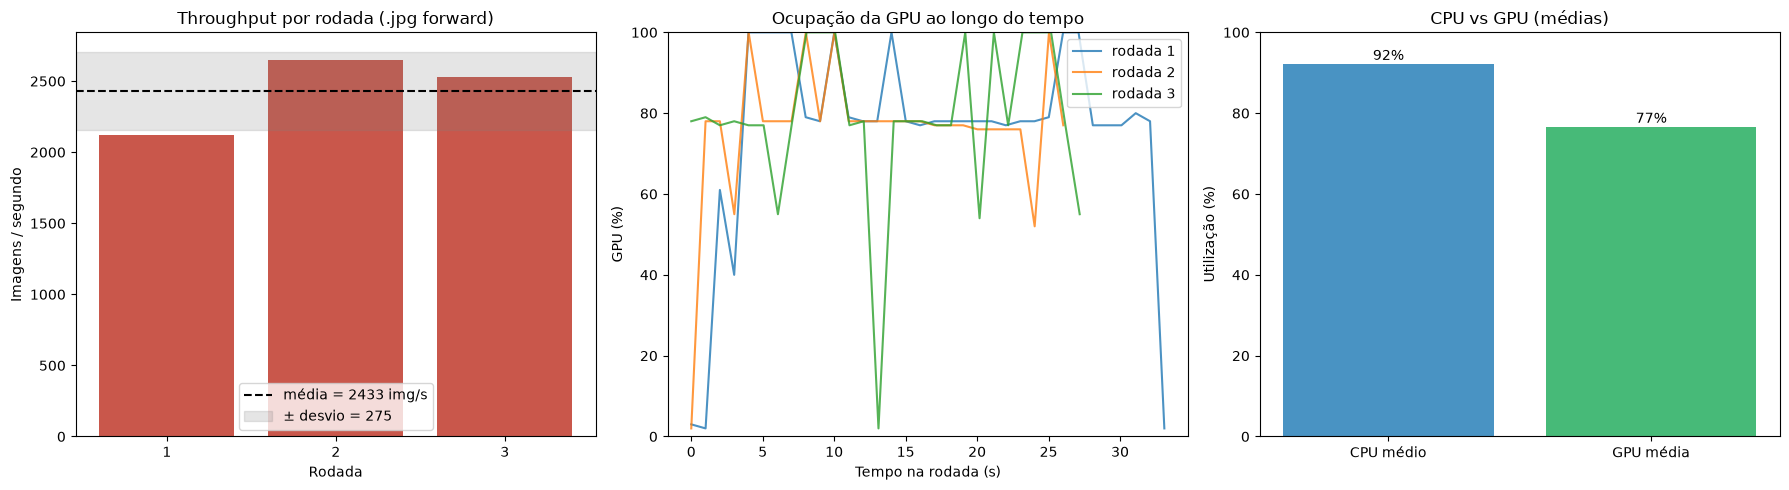

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) Throughput por rodada + media/desvio
ax = axes[0]
ax.bar(summary_df["round"].astype(str), summary_df["throughput_img_s"], color="#c0392b", alpha=0.85)
ax.axhline(tp_mean, color="black", ls="--", label=f"média = {tp_mean:.0f} img/s")
ax.axhspan(tp_mean - tp_std, tp_mean + tp_std, color="gray", alpha=0.2, label=f"± desvio = {tp_std:.0f}")
ax.set_title("Throughput por rodada (.jpg forward)")
ax.set_xlabel("Rodada"); ax.set_ylabel("Imagens / segundo"); ax.legend()

# (2) Utilizacao da GPU ao longo do tempo, por rodada
ax = axes[1]
for r, g in raw_df.groupby("round"):
    ax.plot(g["t_rel"], g["gpu_util_pct"], label=f"rodada {r}", alpha=0.8)
ax.set_title("Ocupação da GPU ao longo do tempo")
ax.set_xlabel("Tempo na rodada (s)"); ax.set_ylabel("GPU (%)")
ax.set_ylim(0, 100); ax.legend()

# (3) CPU vs GPU medios (o contraste que prova o starvation)
ax = axes[2]
ax.bar(["CPU médio", "GPU média"],
       [stats["cpu_mean_pct"], stats["gpu_util_mean_pct"]],
       color=["#2980b9", "#27ae60"], alpha=0.85)
ax.set_title("CPU vs GPU (médias)")
ax.set_ylabel("Utilização (%)"); ax.set_ylim(0, 100)
for i, v in enumerate([stats["cpu_mean_pct"], stats["gpu_util_mean_pct"]]):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "jpg_forward_plots.png", dpi=120, bbox_inches="tight")
plt.show()

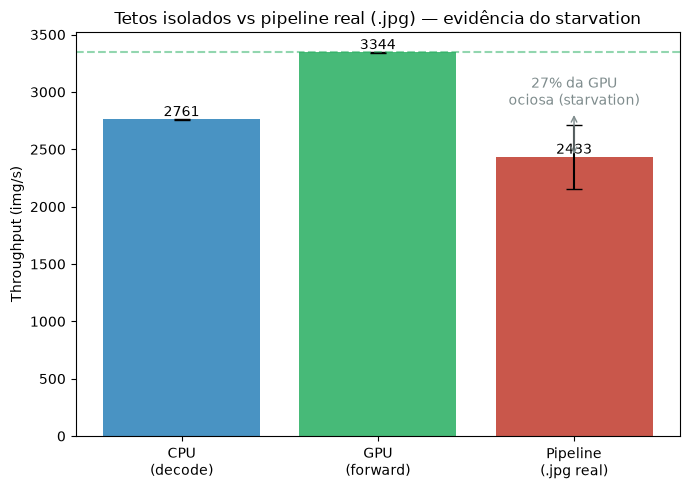

In [10]:
# Grafico-sintese (img/s): tetos isolados vs pipeline real -> tamanho do starvation
fig, ax = plt.subplots(figsize=(7, 5))
labels = ["CPU\n(decode)", "GPU\n(forward)", "Pipeline\n(.jpg real)"]
vals   = [cpu_ceiling, gpu_ceiling, tp_mean]
errs   = [cpu_ceiling_std, gpu_ceiling_std, tp_std]
bars = ax.bar(labels, vals, yerr=errs, capsize=6,
              color=["#2980b9", "#27ae60", "#c0392b"], alpha=0.85)
ax.set_ylabel("Throughput (img/s)")
ax.set_title("Tetos isolados vs pipeline real (.jpg) — evidência do starvation")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.0f}", ha="center", va="bottom")

# Seta mostrando a capacidade de GPU desperdicada (entre o pipeline e o teto da GPU)
ax.axhline(gpu_ceiling, color="#27ae60", ls="--", alpha=0.5)
ax.annotate(f"{gpu_waste_pct:.0f}% da GPU\nociosa (starvation)",
            xy=(2, tp_mean), xytext=(2, (tp_mean + gpu_ceiling) / 2),
            ha="center", color="#7f8c8d", fontsize=10,
            arrowprops=dict(arrowstyle="<->", color="#7f8c8d"))

plt.tight_layout()
plt.savefig(RESULTS_DIR / "jpg_forward_ceilings.png", dpi=120, bbox_inches="tight")
plt.show()